In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOK SABHA DATA

In [2]:
df = pd.read_csv("ind-lok-sabha.csv")

In [3]:
display(df.head())
#display(df.tail())

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [4]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (73081, 11)
Rows: 73081
Columns: 11


In [5]:
#print(df.columns.tolist())
print(df.dtypes)

st_name       object
year           int64
pc_no          int64
pc_name       object
pc_type       object
cand_name     object
cand_sex      object
partyname     object
partyabbre    object
totvotpoll     int64
electors       int64
dtype: object


In [6]:
display(df.describe(include="all"))

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
count,73081,73081.000000,73081.000000,73081,65011,73081,72539,73081,73081,73081.000000,7.308100e+04
unique,43,NaN,NaN,769,4,56601,3,1424,1071,NaN,NaN
top,Uttar Pradesh,NaN,NaN,Belgaum,GEN,None Of The Above,M,Independent,IND,NaN,NaN
freq,14791,NaN,NaN,567,54862,543,68885,31458,41127,NaN,NaN
mean,NaN,1996.779505,22.311490,NaN,NaN,NaN,NaN,NaN,NaN,49834.760266,1.122277e+06
std,NaN,10.432527,19.039793,NaN,NaN,NaN,NaN,NaN,NaN,104893.319706,3.560049e+05
min,NaN,1977.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.947100e+04
25%,NaN,1989.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,872.000000,9.129850e+05
50%,NaN,1996.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,2743.000000,1.099503e+06
75%,NaN,2004.000000,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,19185.000000,1.329086e+06


In [7]:
df.isna().sum() 
# OR *df.isnull().sum()

st_name          0
year             0
pc_no            0
pc_name          0
pc_type       8070
cand_name        0
cand_sex       542
partyname        0
partyabbre       0
totvotpoll       0
electors         0
dtype: int64

# For missing values
#1.remove rows with missing values  --->  *df.dropna()   

#2.remove rows where specific column is missing values -->*df.dropna(subset=['partyname'])

#3.fill missing values with a constant       --> *df.fillna('Unknown')

#4.Fill a specific column  --> *df['partyname'] = df['partyname'].fillna('Unknown')

In [8]:
df[df['pc_type'].isna()]['year'].value_counts().sort_index()

year
2009    8070
Name: count, dtype: int64

In [9]:
df[df['year'] == 2009]['pc_type'].value_counts(dropna=False)

pc_type
NaN    8070
Name: count, dtype: int64

In [10]:
df['pc_type'] = df['pc_type'].fillna('Unknown')

In [11]:
# Unique values of every column
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique())


st_name
43

year
11

pc_no
85

pc_name
769

pc_type
5

cand_name
56601

cand_sex
3

partyname
1424

partyabbre
1071

totvotpoll
29173

electors
5911


In [12]:
#duplicate rows
df.duplicated().sum()

np.int64(1)

In [13]:
df[df.duplicated()]

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
19110,Haryana,1989,8,Bhiwani,GEN,Ishwar,M,Independent,IND,57,944629


In [14]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [15]:
df['cand_sex'] = df['cand_sex'].fillna('Unknown')

In [16]:
# Top 20 states by candidate count
df['st_name'].value_counts().head(20)

st_name
Uttar Pradesh                          14791
Bihar                                   7727
Maharashtra                             6458
Tamil Nadu                              5309
Andhra Pradesh                          5236
Madhya Pradesh                          5196
West Bengal                             3648
Karnataka                               3624
Rajasthan                               3433
Gujarat                                 2946
Haryana                                 2065
Kerala                                  1881
National Capital Territory Of Delhi     1823
Punjab                                  1715
Orissa                                  1354
Assam                                   1123
Jammu & Kashmir                          695
Jharkhand                                685
Himachal Pradesh                         347
Chhattisgarh                             324
Name: count, dtype: int64

In [17]:
# Top 20 Political parties by participation
df['partyname'].value_counts().head(20)

partyname
Independent                           31457
IND                                    5619
Independents                           4050
Indian National Congress               3919
Bharatiya Janata Party                 2329
Bahujan Samaj Party                    1670
Janata Dal                              943
BSP                                     938
INC                                     881
BJP                                     792
Janata Party                            712
Samajwadi Party                         621
Communist Party Of India (Marxist)      608
NOTA                                    543
Communist Party Of India                507
Indian Natioanl Congress (I)            492
SP                                      434
Janta Party                             432
AAAP                                    432
Bharatiya Lok Dal                       405
Name: count, dtype: int64

In [18]:
def abbreviate(name):
    return ''.join(word[0] for word in name.split())

df['partyabbre'] = df['partyname'].apply(abbreviate)

In [19]:
# Top 20 Political parties by participation
df['partyabbre'].value_counts().head(20)

partyabbre
I        42132
INC       3919
BJP       2564
B         2273
BSP       1688
JP        1286
S         1271
A         1127
JD         956
SP         796
N          737
INC(       723
CPOI(      653
J          557
CPOI       515
C          470
JP(        465
R          462
BLD        405
DP         396
Name: count, dtype: int64

In [20]:
# Gender distribution
df['cand_sex'].value_counts()

cand_sex
M          68884
F           3648
Unknown      542
O              6
Name: count, dtype: int64

# Vidhan Sabha data

In [21]:
df2 = pd.read_csv("ind-vidhan-sabha.csv")

In [22]:
display(df2.head())
#display(df2.tail())

,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Manabala Ramarao,M,Independent,IND,813.0,83247
1,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Appadu Sahu,M,Independent,IND,1743.0,83247
2,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Uppada Rangababu,M,Indian National Congress,INC,4427.0,83247
3,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Kalla Balarama Swamy,M,Indian National Congress (I),INC(I),19805.0,83247
4,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Bendalam Venkatesam Sarma,M,Janata Party,JNP,34251.0,83247


In [23]:
print("Shape:", df2.shape)
print("Rows:", df2.shape[0])
print("Columns:", df2.shape[1])

Shape: (327294, 11)
Rows: 327294
Columns: 11


In [24]:
print(df2.columns.tolist())
print(df2.dtypes)

['st_name', 'year', 'ac_no', 'ac_name', 'ac_type', 'cand_name', 'cand_sex', 'partyname', 'partyabbre', 'totvotpoll', 'electors']
st_name        object
year          float64
ac_no           int64
ac_name        object
ac_type        object
cand_name      object
cand_sex       object
partyname      object
partyabbre     object
totvotpoll    float64
electors        int64
dtype: object


In [25]:
display(df2.describe(include="all"))

,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
count,327294,327294.000000,327294.000000,311211,327294,327294,321992,327294,324588,327287.000000,3.272940e+05
unique,30,NaN,NaN,6247,5,220531,3,1663,1285,NaN,NaN
top,Uttar Pradesh,NaN,NaN,Modakurichi,GEN,None Of The Above,M,Independent,IND,NaN,NaN
freq,60206,NaN,NaN,1116,264812,1779,307098,84448,161929,NaN,NaN
mean,NaN,1996.143765,127.910918,NaN,NaN,NaN,NaN,NaN,NaN,9299.673421,1.684289e+05
std,NaN,10.993383,96.626260,NaN,NaN,NaN,NaN,NaN,NaN,17025.780928,8.316493e+04
min,NaN,1977.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000e+00
25%,NaN,1989.000000,49.000000,NaN,NaN,NaN,NaN,NaN,NaN,289.000000,1.186640e+05
50%,NaN,1995.000000,106.000000,NaN,NaN,NaN,NaN,NaN,NaN,1022.000000,1.578260e+05
75%,NaN,2006.000000,193.000000,NaN,NaN,NaN,NaN,NaN,NaN,9182.000000,2.010310e+05


In [26]:
# Top 20 Political parties by participation
df2['partyname'].value_counts().head(20)

partyname
Independent                           84448
Independents                          53452
IND                                   25180
Indian National Congress              21848
Bahujan Samaj Party                    8251
Bharatiya Janata Party                 8115
INC                                    5515
BJP                                    5158
BSP                                    4822
Janata Party                           4425
Bhartiya Janta Party                   3813
Samajwadi Party                        3397
Janata Dal                             3230
Communist Party Of India               3205
Doordarshi Party                       3184
Communist Party Of India (Marxist)     3111
Indian National Congress (I)           3028
Janta Party                            2351
Janata Party (Jp)                      1893
NOTA                                   1779
Name: count, dtype: int64

In [27]:
def abbreviate(name):
    return ''.join(word[0] for word in name.split())

df2['partyabbre'] = df2['partyname'].apply(abbreviate)

In [28]:
# Top 20 Political parties by participation
df2['partyabbre'].value_counts().head(20)

partyabbre
I        169396
INC       21848
BJP       14903
B         12074
BSP        8256
JP         7040
S          5821
SP         4292
JD         4147
INC(       4090
N          3624
DP         3620
J          3481
CPOI(      3224
CPOI       3205
A          2890
R          2539
C          1973
JP(        1912
JD(        1836
Name: count, dtype: int64

In [29]:
df2.isna().sum() 
# OR *df2.isnull().sum()

st_name           0
year              0
ac_no             0
ac_name       16083
ac_type           0
cand_name         0
cand_sex       5302
partyname         0
partyabbre        0
totvotpoll        7
electors          0
dtype: int64

In [30]:
df2[df2['partyabbre'].isna()][['partyname']].drop_duplicates()

,partyname


In [31]:
df2['partyabbre'].isna().sum()

np.int64(0)

In [32]:
# For missing values
#1.remove rows with missing values  --->  *df.dropna()   

#2.remove rows where specific column is missing values -->*df.dropna(subset=['partyname'])

#3.fill missing values with a constant       --> *df.fillna('Unknown')

#4.Fill a specific column  --> *df['partyname'] = df['partyname'].fillna('Unknown')

In [33]:
df2['cand_sex'] = df2['cand_sex'].fillna('Unknown')

In [34]:
df2[df2['ac_name'].isna()]['year'].value_counts().sort_index()

year
1978.0    1819
1980.0    1537
1985.0    2230
1990.0    3764
1995.0    4727
1999.0    2006
Name: count, dtype: int64

In [35]:
df2[df2['ac_name'].isna()]['st_name'].value_counts().sort_index()

st_name
Maharashtra    16083
Name: count, dtype: int64

In [36]:
# Unique values of every column
for col in df2.columns:
    print(f"\n{col}")
    print(df2[col].nunique())


st_name
30

year
37

ac_no
425

ac_name
6247

ac_type
5

cand_name
220531

cand_sex
4

partyname
1663

partyabbre
673

totvotpoll
53067

electors
31291


In [37]:
#duplicate rows
df2.duplicated().sum()

np.int64(49)

In [38]:
df[df.duplicated()]

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors


In [39]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [40]:
# Top 20 states by candidate count
df2['st_name'].value_counts().head(20)

st_name
Uttar Pradesh                          60206
Bihar                                  38064
Maharashtra                            26727
Madhya Pradesh                         25062
Andhra Pradesh                         22012
Tamil Nadu                             22009
Karnataka                              17111
Rajasthan                              17051
West Bengal                            13334
Haryana                                12190
Gujarat                                11604
Odisha                                  8991
Assam                                   8321
Kerala                                  7712
Punjab                                  6589
National Capital Territory Of Delhi     6083
Jammu & Kashmir                         4978
Jharkhand                               4098
Himachal Pradesh                        3507
Chhattisgarh                            2961
Name: count, dtype: int64

In [41]:
# Top 20 Political parties by participation
df2['partyname'].value_counts().head(20)

partyname
Independent                           84448
Independents                          53452
IND                                   25180
Indian National Congress              21848
Bahujan Samaj Party                    8251
Bharatiya Janata Party                 8115
INC                                    5515
BJP                                    5158
BSP                                    4822
Janata Party                           4425
Bhartiya Janta Party                   3813
Samajwadi Party                        3397
Janata Dal                             3230
Communist Party Of India               3205
Doordarshi Party                       3184
Communist Party Of India (Marxist)     3111
Indian National Congress (I)           3028
Janta Party                            2351
Janata Party (Jp)                      1893
NOTA                                   1779
Name: count, dtype: int64

In [42]:
# Top 20 Political parties by participation
df2['partyabbre'].value_counts().head(20)

partyabbre
I        169396
INC       21848
BJP       14903
B         12074
BSP        8256
JP         7040
S          5821
SP         4292
JD         4147
INC(       4090
N          3624
DP         3620
J          3481
CPOI(      3224
CPOI       3205
A          2890
R          2539
C          1973
JP(        1912
JD(        1836
Name: count, dtype: int64

In [43]:
# Gender distribution
df['cand_sex'].value_counts()

cand_sex
M          68884
F           3648
Unknown      542
O              6
Name: count, dtype: int64

# Pie Chart for Assembly Constituency type(ac_type) 

In [44]:
counts = df2['ac_type'].value_counts()
print(counts)

ac_type
GEN      264812
SC        41821
ST        20625
BL           30
SANGH         6
Name: count, dtype: int64


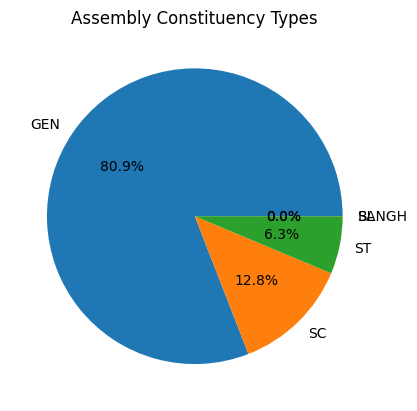

In [45]:
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)
plt.title("Assembly Constituency Types")
plt.show()

In [46]:
sex=df2['cand_sex'].value_counts()
sex = sex.drop('Unknown')
print(sex)

cand_sex
M    307098
F     14883
O        11
Name: count, dtype: int64


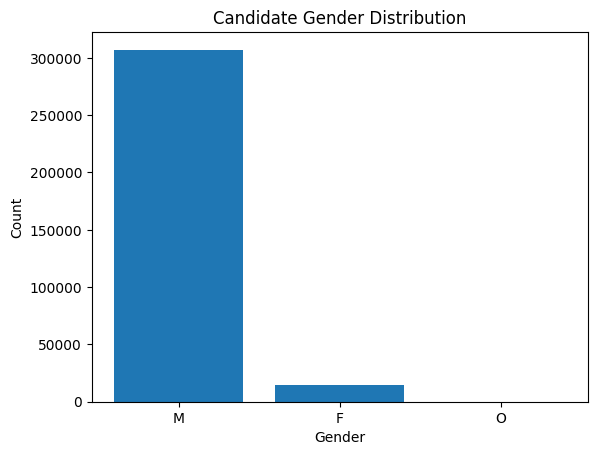

In [47]:
plt.bar(sex.index,sex.values)   #--> #1.category name 2. their values
plt.title("Candidate Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("ind-vidhan-sabha.csv")

In [50]:
# First 5 rows
df.head()

,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Manabala Ramarao,M,Independent,IND,813.0,83247
1,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Appadu Sahu,M,Independent,IND,1743.0,83247
2,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Uppada Rangababu,M,Indian National Congress,INC,4427.0,83247
3,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Kalla Balarama Swamy,M,Indian National Congress (I),INC(I),19805.0,83247
4,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Bendalam Venkatesam Sarma,M,Janata Party,JNP,34251.0,83247


In [51]:
# Last 5 rows
df.tail()

,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
327289,West Bengal,2011.0,294,Murarai,GEN,Ajrail Md,M,IND,IND,2471.0,189320
327290,West Bengal,2011.0,294,Murarai,GEN,Shiblal Sardar,M,BSP,BSP,3074.0,189320
327291,West Bengal,2011.0,294,Murarai,GEN,Sudhiranjan Das Goswami,M,BJP,BJP,4961.0,189320
327292,West Bengal,2011.0,294,Murarai,GEN,Elahi Kamre Dr,M,CPM,CPM,73414.0,189320
327293,West Bengal,2011.0,294,Murarai,GEN,Nure Alam Chowdhury,M,AITC,AITC,77817.0,189320


In [52]:
# Shape of dataset
df.shape

(327294, 11)

In [53]:
# Column names
df.columns

Index(['st_name', 'year', 'ac_no', 'ac_name', 'ac_type', 'cand_name',
       'cand_sex', 'partyname', 'partyabbre', 'totvotpoll', 'electors'],
      dtype='object')

In [54]:
# Dataset summary including categorical columns
df.describe(include='all')

,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
count,327294,327294.000000,327294.000000,311211,327294,327294,321992,327294,324588,327287.000000,3.272940e+05
unique,30,NaN,NaN,6247,5,220531,3,1663,1285,NaN,NaN
top,Uttar Pradesh,NaN,NaN,Modakurichi,GEN,None Of The Above,M,Independent,IND,NaN,NaN
freq,60206,NaN,NaN,1116,264812,1779,307098,84448,161929,NaN,NaN
mean,NaN,1996.143765,127.910918,NaN,NaN,NaN,NaN,NaN,NaN,9299.673421,1.684289e+05
std,NaN,10.993383,96.626260,NaN,NaN,NaN,NaN,NaN,NaN,17025.780928,8.316493e+04
min,NaN,1977.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000e+00
25%,NaN,1989.000000,49.000000,NaN,NaN,NaN,NaN,NaN,NaN,289.000000,1.186640e+05
50%,NaN,1995.000000,106.000000,NaN,NaN,NaN,NaN,NaN,NaN,1022.000000,1.578260e+05
75%,NaN,2006.000000,193.000000,NaN,NaN,NaN,NaN,NaN,NaN,9182.000000,2.010310e+05


In [55]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327294 entries, 0 to 327293
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   st_name     327294 non-null  object 
 1   year        327294 non-null  float64
 2   ac_no       327294 non-null  int64  
 3   ac_name     311211 non-null  object 
 4   ac_type     327294 non-null  object 
 5   cand_name   327294 non-null  object 
 6   cand_sex    321992 non-null  object 
 7   partyname   327294 non-null  object 
 8   partyabbre  324588 non-null  object 
 9   totvotpoll  327287 non-null  float64
 10  electors    327294 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 27.5+ MB


In [ ]:
# Unique values count in each column
df.nunique()

In [ ]:
#analyse and clean up for lok sabha dataset(df_lok)

In [ ]:
df_lok['cand_sex'] = df_lok['cand_sex'].fillna('U')
df_lok['pc_type'] = df_lok['pc_type'].fillna('unknown')
df_lok.isnull().sum()

In [ ]:
df_lok['partyabbre'].value_counts().head(50).sort_index()

In [ ]:
df_lok['partyabbre'] = df_lok['partyabbre'].replace({'INC(I)':'INC'})

In [ ]:
df_lok['partyabbre'].value_counts().head(50).sort_index()

In [ ]:
# Missing values
df.isnull().sum()

In [ ]:
# Display all column names one by one
for col in df.columns:
    print(col)

In [ ]:
# Unique values of every column
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique())

In [ ]:
# Value counts for every column
for col in df.columns:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts().head())

In [12]:
# Number of states
df['st_name'].nunique()

30

In [13]:
# Number of years covered
df['year'].nunique()

37

In [14]:
# Number of constituencies
df['ac_name'].nunique()

6247

In [15]:
# Number of candidates
df['cand_name'].nunique()

220531

In [16]:
# Number of political parties
df['partyname'].nunique()

1663

In [17]:
# List all states
df['st_name'].unique()

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'National Capital Territory Of Delhi', 'Odisha',
       'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

In [18]:
# Elections year range
df['year'].min(), df['year'].max()

(np.float64(1977.0), np.float64(2015.0))

In [ ]:
#step 1: Create mapping from existing data (most frequent abbrev per partyname)
valid_pairs = df_vidhan.dropna(subset=['partyname','partyabbre'])
party_abbrev_map = (
    valid_pairs.groupby('partyname')['partyabbre']
    .agg(lambda x:x.value_counts().idxmax())
    .to_dict()

#step 2. Fill missing partyabbre using the mapping
df_vidhan['partyabbre'] = ad_vidhan.apply(
    lambda row: party_abbrev_map.get(['partyname'],row['partyabbre']),axis=1)

#step 3: Fill any missing values with 'IND'
df_vidhan['partyabbre'] = df_vidhan['partyabbre'].fillna('IND')

In [ ]:
df_vidhan['partyabbre'].value_counts().head(50).sort_index()

In [ ]:
df_vidhan['partyabbre'] = df_vidhan['partyabbre'].replace({'INC(I)':'INC'})

In [ ]:
df_vidhan['partyabbre'].value_counts().head(50).sort_index()

In [ ]:
# Convert 'year' to integer
df_vidhan['year'] = df_vidhan['year'].astype(int)

#fill missing 'cand_sex' with unknown 'U'
df_vidhan['cand_sex'] =df_vidhan['cand_sex'].fillna('U')

#Drop rows with missing values 'totvotpoll'
df_vidhan = df_vidhan.dropna(subset=['totvotpoll'])

In [ ]:
# step 1: Build mapping of (st_name, ac_no) to most common ac_name
ac_name_map = (
    df_vidhan[~df_vidhan['ac_name'].insa()].groupby(['st_name','ac_no'])['ac_name'].agg(lambda x:x.value_counts().idmax())
)

#step 2: Fill missing ac_name using that mapping
def fill_ac_name(rows):
    if pd.isna(row['ac_name']):
        return ac_name_map.get((row['st_name'],row['ac_no']),np.nan)
    return row['ac_name']
    
df_vidhan['ac_name'] = df_vidhan.apply(fill_ac_name,axis=1)

#step 3: Check remaining missing values
print("Missing ac_name after fill:", df_vidhan['ac_name'].isna().sum())

In [ ]:
df_vidhan.head()

In [ ]:
df_vidhan.isnull().sum()

In [ ]:
#Analyse the scale and variety of Vidhan Sabha election Dataset

In [ ]:
#Unique Value
print("Unique Counts")
print("Unique States:",df_vidhan['st_name'].nunique())
print("Years Covered:",df_vidhan['year'].nunique())
print("Unique Constituencies",df_vidhan['ac_no'].nunique()))
print("Unique Parties:",df_vidhan['partyabbre'].nunique())

In [ ]:
#visualization

In [ ]:
# Candidate Gender Distribution
import matplotlib.pyplot as plt
import seaborn as sns

#prepare gender distribution data
gender_counts = df_vidhan['cand_sex'].values_counts().reset_index()
gender_counts.columns = ['Gender','Count']
print(gender_counts)

#pie chart
plt.figure(figsize =(6,6))
plt.pie(
    gender_counts['Count'],
    label=gender_counts['Gender'],
    autopct=%1.1f%%,
    startangle=140,
    colors=sns.color_palette('pastel')
)
plt.title('Candidate Gender Distribution')
plt.axis('equal')   #equal aspect ratio ensures pie is a circle
plt.tight_layout()
plt.show()

In [ ]:
#Average Candidate per seat per year
candidate_per_seat = df_vidhan.groupby(['year','ac_no'])['cand_name'].nunique())
avg_candidate_per_seat = candidate_per_seat.groupby('year').mean().reset_index()
avg_candidate_per_seat.columns = ['year','Avg_Candidate_Per_Seat']
print(avg_candidate_per_seat)

#Line Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=avg_candidate_per_seat, x='Year', y='Avg_Candidate_Per_Seat', marker='o')
plt.title('avg_candidate_per_seat')
plt.ylabel('Avg Candidate')
plt.xlabel('Year')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
Voter turnout% = ((Total Electors)/(Total Votes Polled) )*100

In [ ]:
# voter turnout percent by year
# step 1. Get constituency-level data (one row per seat per year)
constituency_turnout = (
    df_vidhan.groupby(['year','st_name','ac_no'])[['totvotpoll','electors']]
        .agg({'totvotpoll':'max','electors':'max'})
           .rest_index()
)

#step 2: Aggregate to year level
yearly_turnout = constituency_turnout.groupby('year')[['totvotpoll','electors']].sum().reset_index()

#step 3: Compute voter Turnout%
yearly_turnout['voter_turnout_percent'] = (yearly_turnout['totvotpoll']/ yearly_turnout['electors']) * 100
print(yearly_turnout)   

#step 4: Plot the correct turnout
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_turnout, x='Year', y='voter_turnout_percent', marker='o',color='green')
plt.title('voter_turnout_percent by year')
plt.ylabel('voter_turnout (%)')
plt.xlabel('Year')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# step 1: Count number of candidates per party and select top 10
party_counts = df_vidhan['partyabbre'].value_counts().nlargest(10).reset_index()
party_counts.columns = ['Party','Candidate_counts']

#step 2: Plot using hue and suppress legend
plt.figure(figsize=(12,6))
sns.barplot(
    data=party_counts,
    x='Candidate_count', 
    y='Party', 
    hue = 'Party',
    dodge=False,
    palette='viridis',
    legend=False
)
plt.title('Top 10 Parties by number of Candidates(Vidhan Sabha)')
plt.ylabel('Number of candidates')
plt.xlabel('party')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#New subset of data (winners_df)

In [ ]:
winners_df = df_vidhan.loc[df_vidhan.groupby(['year','st_name','ac_no'])['totvol'
#print(winners_df)

#display the top winners
print(winners_df[winners_df['st_name'] == 'Rajasthan'][['st_name','year','ac_no','ac_name','cand_name','partyabbre','totvo'
                                                        .sort_values(by='year').head(8)rest_index()

In [ ]:
#step 1.Total votes by party (Vote share )
party_voters = df_vidhan.groupby('partyabbre')['totvotpoll'].sum()
total_voters = party_votes.sum()
party_vote_share = (party_votes / total_votes * 100).reset_index()
party_vote_share.columns = ['Party','Seat_Share']

#print(party_vote_share)

#step 2. Total winners by party (Seat share)
party_seats = winner_df['partyabbre'].value_counts(normalization=True) * 100
party_seat_share = party_seats.reset_index()
party_seat_share.columns = ['Party','Seat_Share']

#print(party_seat_share)

#step 3: Merge vote share and seat share
share_df = pd.merge(party_vote_share,party_seat_share, on='Party')
#print(share_df)

#step 4: top 10 parties by vote share
top_parties = share_df.sort_values('Vote_share',ascending=False).head(10)
print(top_parties)

#step5: Plot
plt.figure(figsize=(12,6))
bar_width = 0.4
x = range(len(top_parties))

plt.barh(x, top_parties['Vote_Share'],height=bar_width, label='Vote_Share %',color='skyblue')
plt.barh([p + bar_width for p in x],  top_parties['Seat_Share'], height=bar_width, label='Vote Share %', color='skyblue')

plt.yticks([p+ bar-width / 2 for p in x], top_parties['Party'])
plt.xlabel('Percentage')
plt.title('Vote Share vs Seat Share (Top 10 Parties) Nationally')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Filter for Gujrat only
winners_gujrat = winners_df[winners_df['st_name'] == 'Gujrat'].copy()

# 2. Find top 3 parties in Gujrat by total seats won
top_3_parties = winners_gujrat['partyabbre'].value_counts().nlargst(3).index.tolist()

#print(top_3_parties)

#3 .Filter to only htose top 3 parties
winners_gujrat_top3 = winners_gujrat[winners_gujrat['partyabbre'].isin(top_3_parties)]

#4. Seats won per year by party
party_seats_year = (
    winners_gujrat_top_3.groupby(['year','partyabbre']).size().reset_index(name='seats')
)
#print(party_seats_year)

#5 Seats won
plt.figure(figsize=(12,6))
sns.barplot(
    data=party_seats_per_year,
    x='year', 
    y='seats', 
    hue = 'partyabbre',
    dodge=False,
    palette='viridis'
)
plt.title('Seats won by top 3 parties in gujrat(Vidhan Sabha)')
plt.ylabel('Number of seats')
plt.xlabel('year')
plt.xticks(rotation=45)
plt.legend(title='Party', bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#
#
gujarat_df = df_vidhan[df_vidhan['st_name'] == 'Gujarat'].copy()

#2.
party_votes = (
    gujarart_df.groupby(['year','partyabbre'])['totvotpoll'].sum().reset_index()
)
#print(part_votes)

#3.
total_votes_per_year = (
    gujarat_df.groupby('year')['totvotpoll']
        .sum()
        .reset_index()
    .rename(columns={'totvotpoll':'total_vote'})
)
#print(total_votes_per_year)

#4.
party_vote_share = pd.merge(party_votes,total_votes_per_year,on='year')
party_vote_share['vote_share_percent'] = (party_vote_share['totvotpoll']/party_vote_share['total_votes'])
#print(party_vote_share)

#5.
top_parties = (
    gujarat_df.groupby('partyabbre')['totvotpoll']
    .sum()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)
#print(top_parties)

# 6.
top_vote_share = party_vote_share[party_vote_share['partyabbre'].isin(top_parties)]
#print(top_vote_share)

#7.
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_vote_share,
    x='year', 
    y='vote_share_percent', 
    hue = 'partyabbre',
    marker='o'
)
plt.title('Vote Share by top 3 parties in gujrat(All Candidates)')
plt.ylabel('Vote Share(%)')
plt.grid(True)
plt.xlabel('year')
plt.xticks(rotation=45)
plt.legend(title='Party', bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

Q. By How Many votes did winner prities defeated runners-up in Gujarat election,and how has this winning margin changed over time?

In [ ]:
#
df_vidhan['vote_share_percent'] = (df_vidhan['totvotpoll']/df_vidhan['electors'])*100
#print(df_vidhan.head())

#1.
gujarat_df = df_vidhan[df_vidhan['st_name']==Gujarat].copy()

#3.
gujarat_df['rank'] = gujarat_df.groupby(['year','ac_no'])['totvotpoll'].rank(method='first',acsend=False)
#print(gujarat_df)

#3.
winners = gujarat_df[gujarat_df['rank']== 1].copy()
runners_up =gujarat_df[gujarat_df['rank']== 2].copy()

#4.
merged = pd.merge(
    winners,
    runners_up,
    on=['year','ac_no'],
    suffixes = ('_winner','_runners_up')
)
#print(merged)

merged['vote_margin'] = merged['totvotpoll_winner'] - merged['totvotpoll_runnerup']

#5.
top_3_parties = winners['partyabbre'].value_counts().nlargest(3).index.tolist()
#print(top_3_parties)

#6.
merged_top3 = merged[merged['partyabbre_winner'].isin(top_3_parties)].copy()

#7.
plt.figure(figsize=(10,5))
plt.histplot(merged_top3['vote_margin'],bins=30,kde=True, color='navy')
plt.title('Distributiom of vote margin(Top 3 parties, Gujarat(All Candidates)')
plt.ylabel('Number of COnstituency ')
plt.grid(True)
plt.xlabel('Vote Margin (winner - Runner-up)')
plt.tight_layout()
plt.show()

#8. Average vote mar
avg_margin_year_party =(
    merged_top3.groupby(['year','partyabbre_winner'])['vote_margin']
    .mean()
    .rese_index()
    .rename(columns={'partyabbre_winner':'party'})
)

#9.
plt.figure(figsize=(12,6))
sns.lineplot(
    data=avg_margin_year_party,
    x='year', 
    y='vote_margin', 
    hue = 'party',
    marker='o'
)
plt.title('Average Vote Margin per year by Party (top 3 parties in gujrat)')
plt.ylabel('Average Vote Margin')
plt.grid(True)
plt.xlabel('year')
plt.xticks(rotation=45)
plt.legend(title='Party', bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

#10. Identify Outliers Years ( high/low margins)
q1 = avg_margin_year_party['vote_margin']
q3 = avg_margin_year_party
outliers = avg_margin_year_party[
    (avg_margin_year_party['vote_margin'] < q1) |
    (avg_margin_year_party['vote_margin'] > q3)
]

#optional: Display outliers
print("* Outliers Years in Vote Margin Trends (Top 3 Parties, Gujarat):")
print(outliers.sort_values(by='vote_margin',ascending=False))

Q1.


Q2.

In [ ]:
#
constituency_turnout = (
    df_vidhan.groupby(['st_name','year','ac_no'])[['totvotpoll','electors']]
    .agg({'totvotpoll':'sum','electors':'max'})  #max electors per seat,sum of votes
    .reset_index()
)

#2.
state_turnout = (
    constituency_turnout.groupby('st_name')[['totvotpoll','electors']]
    .sum()
    .assign(voter_turnout_percent=lambda x: (x['totvotpoll']/x['electors']*100))
    .sort_values('voter_turnout_percent',ascending=False)['voter_turnout_percent']
)
print(state_turnout.head())

#plot 1:
plt.figure(figsize=(10,8))
ax1 = 
sns.barplot(
    data=avg_margin_year_party,
    x='state_turnout', 
    y='state_turnout.index', 
    hue = 'state_turnout.index',
    palette = 'virdis',
    legend = False
)
plt.title('Voter Turnout by State',fontdict={'fontdict': font_name})
plt.xlabel('Turnout (%)', fontdict={'fontdict': font_name})
plt.grid(True)
plt.ylabel('state Name', fontdict={'fontdict': font_name} )
plt.xticks(fontname = font_name)
plt.yticks(fontname = font_name)

for p in ax1.patches:
    ax1.annotate((f'{p.get_width():.1f}%, (p.get_width() + 1, p.get_y() + p.get_height()/2),
                  ha='left',va='center', fontsize = 10, color='black')
plt.tight_layout()
plt.show()

#3.
state_constituency = 
